In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import json
import boost_histogram as bh
import uproot
from scipy.stats import beta
import hist
import hist.intervals
import awkward as ak

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
loc = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/AODSkimmer/created_ntuples/AllInOne/2022/Signal_Mchi-10p5_dMchi-1p0_ctau-10_ALL.root"

sig_root = uproot.open(loc)
sig_root.keys()
ntuple = sig_root["ntuples/outT"]
ntuple.keys()

['trigFired',
 'eventNum',
 'lumiSec',
 'runNum',
 'trig_HLT_PFMET120_PFMHT120_IDTight',
 'trig_HLT_PFMET120_PFMHT120_IDTight_PFHT60',
 'trig_HLT_PFMET130_PFMHT130_IDTight',
 'trig_HLT_PFMET140_PFMHT140_IDTight',
 'trig_HLT_PFMETNoMu110_PFMHTNoMu110_IDTight_FilterHF',
 'trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight',
 'trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight_FilterHF',
 'trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight_PFHT60',
 'trig_HLT_PFMETNoMu130_PFMHTNoMu130_IDTight',
 'trig_HLT_PFMETNoMu130_PFMHTNoMu130_IDTight_FilterHF',
 'trig_HLT_PFMETNoMu140_PFMHTNoMu140_IDTight',
 'trig_HLT_PFMETNoMu140_PFMHTNoMu140_IDTight_FilterHF',
 'trig_HLT_PFMETTypeOne140_PFMHT140_IDTight',
 'trig_HLT_PFMET105_IsoTrk50',
 'trig_HLT_PFJet40',
 'trig_HLT_PFJet60',
 'trig_HLT_PFJet80',
 'trig_HLT_PFJet140',
 'trig_HLT_PFJet200',
 'trig_HLT_PFJet260',
 'trig_HLT_PFJet320',
 'trig_HLT_PFJet400',
 'trig_HLT_PFJet450',
 'trig_HLT_PFJet500',
 'trig_HLT_PFJet550',
 'trig_HLT_Ele8_CaloIdM_TrackIdM_PFJet30',
 'trig_HL

In [3]:
Electron_genEle=ntuple["GenPos_matchedAllLowPt"].array()
print (Electron_genEle)
# l = ak.flatten(Electron_genEle)

[False, False, False, False, False, False, ... True, False, True, False, False]


In [10]:
Electron_genEle=ntuple["GenEle_pt"].array()
print (Electron_genEle)
ele = len(Electron_genEle)
print ("Total number of gen-ele=",len(Electron_genEle))

Positron_genEle=ntuple["GenPos_pt"].array()
print (Positron_genEle)

pos = len(Positron_genEle)
print ("Total number of gen-pos=",len(Positron_genEle))

total = ele+pos

print ("Total number of gen electrons =", total)

[2.36, 1.33, 3.34, 0.567, 2.57, 1.04, 1.07, ... 9.12, 2.01, 0.619, 8.49, 4.82, 1.5]
Total number of gen-ele= 64604
[1.25, 1.99, 0.29, 2.85, 11.2, 5.51, 7.75, ... 9.04, 3.1, 16.3, 1.9, 8.1, 2.71, 2.23]
Total number of gen-pos= 64604
Total number of gen electrons = 129208


(array([135.,  19.,  11.,   7.,   5.,   5.,   3.,   7.,   2.,   5.]),
 array([1.000e+00, 2.160e+02, 4.310e+02, 6.460e+02, 8.610e+02, 1.076e+03,
        1.291e+03, 1.506e+03, 1.721e+03, 1.936e+03, 2.151e+03]),
 <BarContainer object of 10 artists>)

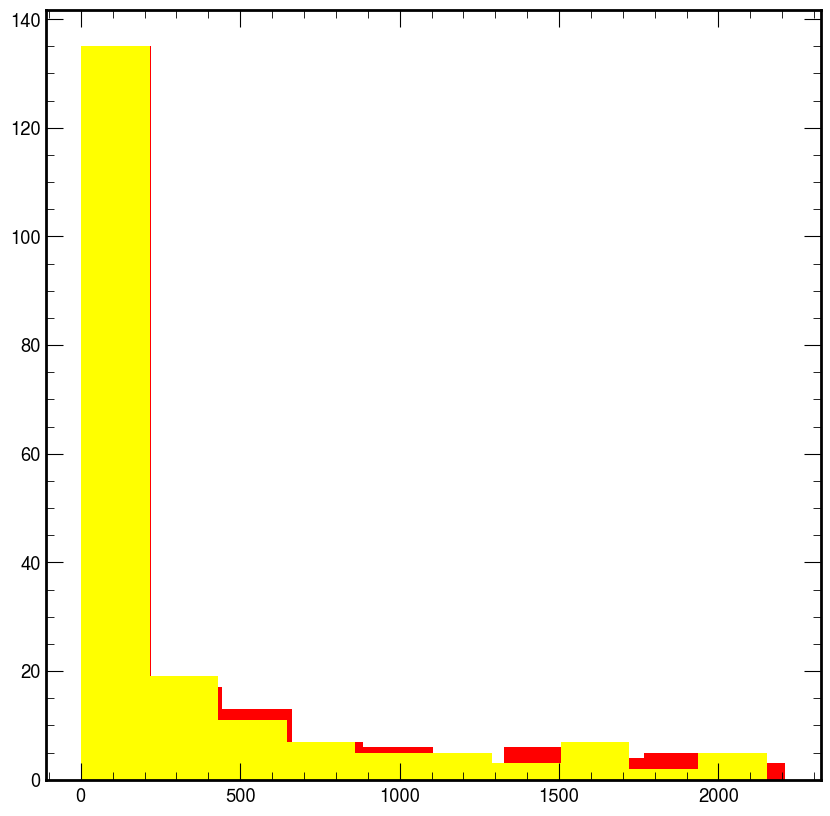

In [12]:
fig, ax = plt.subplots()

bins = np.linspace(0,20,200)

# ax.set_xlabel("dR(low pT ele, regular ele)")
# ax.set_yscale("log")

counts_ele, bins  = np.histogram(Electron_genEle, bins)
counts_pos, bins  = np.histogram(Positron_genEle, bins)


ax.hist(counts_ele, color='red')

ax.hist(counts_pos, color='yellow')

In [5]:
LptElectron_pt=ntuple["LptElectron_pt"].array()

print ("Total number of low-pt ele at the ntuple stage=",len(ak.flatten(LptElectron_pt)))

Total number of low-pt ele at the ntuple stage= 42659


In [6]:
Electron_pt=ntuple["Electron_pt"].array()

print ("Total number of regular ele at the ntuple stage=",(len(ak.flatten(Electron_pt))))


Total number of regular ele at the ntuple stage= 6918
